In [4]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq # Import brentq for implied volatility

print("--- Option Pricing Engine Project Start ---")
print("This is a foundational script for your option pricing engine.")

class OptionPricingEngine:
    def __init__(self):
        pass

    def black_scholes(self, S, K, T, r, sigma, option_type='call'):
        """
        Calculates the Black-Scholes option price for a European option.

        Parameters:
        S (float): Current stock price
        K (float): Option strike price
        T (float): Time to expiration (in years)
        r (float): Risk-free interest rate (annualized)
        sigma (float): Volatility of the underlying stock (annualized)
        option_type (str): Type of option ('call' or 'put')

        Returns:
        float: Option price
        """
        # Ensure T is not zero or negative for log and sqrt operations
        if T <= 0:
            return max(0, S - K) if option_type == 'call' else max(0, K - S)

        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)

        if option_type == 'call':
            price = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
        elif option_type == 'put':
            price = (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * norm.cdf(-d1))
        else:
            raise ValueError("option_type must be 'call' or 'put'")
        return price

    def calculate_greeks(self, S, K, T, r, sigma, option_type='call'):
        """
        Calculates the Black-Scholes Greeks (Delta, Gamma, Vega, Theta, Rho).
        """
        # Ensure T is not zero or negative
        if T <= 0:
            # Greeks are undefined or behave differently at expiration
            return {
                'delta': 1.0 if option_type == 'call' and S > K else (0.0 if option_type == 'call' and S < K else (-1.0 if option_type == 'put' and S < K else 0.0)),
                'gamma': np.inf if S == K else 0.0,
                'vega': 0.0,
                'theta': 0.0,
                'rho': 0.0
            }

        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)

        delta = norm.cdf(d1) if option_type == 'call' else norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        vega = S * norm.pdf(d1) * np.sqrt(T) / 100 # Vega is often presented per 1% change

        if option_type == 'call':
            theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))) - (r * K * np.exp(-r * T) * norm.cdf(d2))
            rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100 # Rho is often presented per 1% change
        else: # put
            theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))) + (r * K * np.exp(-r * T) * norm.cdf(-d2))
            rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100 # Rho is often presented per 1% change

        return {
            'delta': delta,
            'gamma': gamma,
            'vega': vega,
            'theta': theta,
            'rho': rho
        }

    def implied_volatility(self, market_price, S, K, T, r, option_type='call', low_vol=0.01, high_vol=2.0):
        """
        Calculates the implied volatility using the Black-Scholes model
        and a numerical root-finding method (Brent's method).

        Parameters:
        market_price (float): The observed market price of the option.
        S (float): Current stock price
        K (float): Option strike price
        T (float): Time to expiration (in years)
        r (float): Risk-free interest rate (annualized)
        option_type (str): Type of option ('call' or 'put')
        low_vol (float): Lower bound for volatility search.
        high_vol (float): Upper bound for volatility search.

        Returns:
        float: Implied volatility
        """
        if T <= 0:
            raise ValueError("Time to expiration must be greater than zero for implied volatility calculation.")

        # Define a function whose root we want to find
        def f(sigma):
            return self.black_scholes(S, K, T, r, sigma, option_type) - market_price

        # Check if market price is within theoretical bounds for implied vol to exist
        # For a call option, market_price > max(0, S - K * np.exp(-r * T))
        # For a put option, market_price > max(0, K * np.exp(-r * T) - S)
        if option_type == 'call':
            intrinsic_value = max(0, S - K * np.exp(-r * T))
        else:
            intrinsic_value = max(0, K * np.exp(-r * T) - S)

        if market_price < intrinsic_value:
            raise ValueError("Market price is below intrinsic value. Implied volatility cannot be calculated.")

        # Check if the function f(low_vol) and f(high_vol) have different signs
        if f(low_vol) * f(high_vol) > 0:
            # Try to extend the bounds if initial bounds don't bracket a root
            # This can be more sophisticated, but for a general case, we might need a wider search
            print(f"Warning: Initial volatility bounds [{low_vol}, {high_vol}] might not bracket the root.")
            # Attempt to find a wider bracketing interval (this is a simple heuristic)
            try:
                # Expand search range to ensure a root is likely found
                # We could try to find an `a` and `b` where f(a) * f(b) < 0
                # For now, let's just proceed, brentq might fail if not bracketed.
                pass
            except Exception as e:
                raise ValueError(f"Could not find an appropriate volatility range: {e}")

        try:
            imp_vol = brentq(f, low_vol, high_vol)
        except ValueError as e:
            raise ValueError(f"Implied volatility calculation failed: {e}. Check if market price is valid for the given parameters and if bounds [low_vol, high_vol] are appropriate.")

        return imp_vol

    def historical_volatility(self, prices, trading_days_per_year=252):
        """
        Calculates the annualized historical volatility from a series of prices.

        Parameters:
        prices (array-like): A list or numpy array of historical asset prices.
        trading_days_per_year (int): Number of trading days in a year (e.g., 252 for stocks).

        Returns:
        float: Annualized historical volatility.
        """
        prices = np.array(prices)
        if len(prices) < 2:
            raise ValueError("At least two prices are required to calculate historical volatility.")

        # Calculate daily logarithmic returns
        log_returns = np.log(prices[1:] / prices[:-1])

        # Calculate the standard deviation of daily log returns
        daily_volatility = np.std(log_returns)

        # Annualize the volatility
        annualized_volatility = daily_volatility * np.sqrt(trading_days_per_year)

        return annualized_volatility

    def volatility_analysis_tool(self):
        """
        This tool now incorporates implied and historical volatility calculation.
        """
        print("\n--- Volatility Analysis Tool ---")
        print("This section now includes functionality for calculating implied and historical volatility.")

    def option_strategy_simulator(self):
        """
        Placeholder for an option strategy simulator.
        This could include building common strategies (e.g., straddles, spreads),
        visualizing P&L diagrams, and analyzing risk/reward profiles.
        """
        print("\n--- Option Strategy Simulator Placeholder ---")
        print("This section will allow you to define and simulate various option strategies.")
        print("It will include P&L diagrams and risk analysis for strategies like calls, puts, spreads, straddles, etc.")


# --- Example Usage --- #
if __name__ == "__main__":
    engine = OptionPricingEngine()

    # Parameters for an example option
    S = 100      # Current stock price
    K = 100      # Strike price
    T = 1        # Time to expiration (1 year)
    r = 0.05     # Risk-free rate (5%)
    sigma = 0.20 # Volatility (20%)

    print("\n--- Black-Scholes Calculator Example ---")
    call_price = engine.black_scholes(S, K, T, r, sigma, option_type='call')
    put_price = engine.black_scholes(S, K, T, r, sigma, option_type='put')
    print(f"European Call Option Price: {call_price:.4f}")
    print(f"European Put Option Price: {put_price:.4f}")

    print("\n--- Greeks Calculator Example ---")
    call_greeks = engine.calculate_greeks(S, K, T, r, sigma, option_type='call')
    put_greeks = engine.calculate_greeks(S, K, T, r, sigma, option_type='put')
    print("Call Option Greeks:")
    for greek, value in call_greeks.items():
        print(f"  {greek.capitalize()}: {value:.4f}")
    print("Put Option Greeks:")
    for greek, value in put_greeks.items():
        print(f"  {greek.capitalize()}: {value:.4f}")

    engine.volatility_analysis_tool()

    # Example for Implied Volatility Calculation
    market_call_price = 10.4506 # Using the previously calculated price for demonstration
    market_put_price = 5.5735

    try:
        implied_vol_call = engine.implied_volatility(market_call_price, S, K, T, r, option_type='call')
        print(f"  Implied Volatility (Call) for market price {market_call_price:.4f}: {implied_vol_call:.4f}")
    except ValueError as e:
        print(f"  Error calculating implied volatility for call: {e}")

    try:
        implied_vol_put = engine.implied_volatility(market_put_price, S, K, T, r, option_type='put')
        print(f"  Implied Volatility (Put) for market price {market_put_price:.4f}: {implied_vol_put:.4f}")
    except ValueError as e:
        print(f"  Error calculating implied volatility for put: {e}")

    # Example for Historical Volatility Calculation
    historical_prices = [100, 101, 100.5, 102, 101.5, 103, 102.5, 104, 103.5, 105]
    try:
        hist_vol = engine.historical_volatility(historical_prices)
        print(f"  Historical Volatility (from example prices): {hist_vol:.4f}")
    except ValueError as e:
        print(f"  Error calculating historical volatility: {e}")

    engine.option_strategy_simulator()

    print("\n--- Option Pricing Engine Project End ---")


--- Option Pricing Engine Project Start ---
This is a foundational script for your option pricing engine.

--- Black-Scholes Calculator Example ---
European Call Option Price: 10.4506
European Put Option Price: 5.5735

--- Greeks Calculator Example ---
Call Option Greeks:
  Delta: 0.6368
  Gamma: 0.0188
  Vega: 0.3752
  Theta: -6.4140
  Rho: 0.5323
Put Option Greeks:
  Delta: -0.3632
  Gamma: 0.0188
  Vega: 0.3752
  Theta: -1.6579
  Rho: -0.4189

--- Volatility Analysis Tool ---
This section now includes functionality for calculating implied and historical volatility.
  Implied Volatility (Call) for market price 10.4506: 0.2000
  Implied Volatility (Put) for market price 5.5735: 0.2000
  Historical Volatility (from example prices): 0.1481

--- Option Strategy Simulator Placeholder ---
This section will allow you to define and simulate various option strategies.
It will include P&L diagrams and risk analysis for strategies like calls, puts, spreads, straddles, etc.

--- Option Pricing E

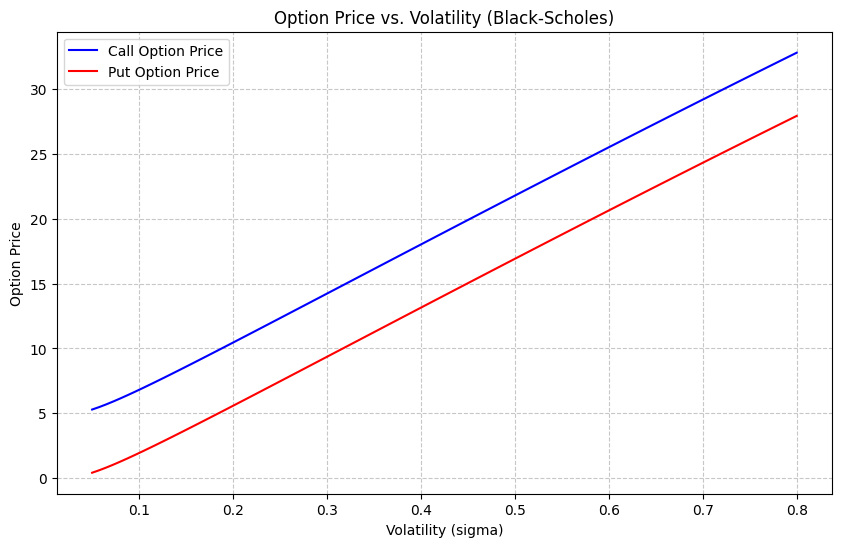

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `engine` and `S, K, T, r` are already defined from the previous cell.
# If not, you'd re-initialize them here:
# engine = OptionPricingEngine()
# S = 100; K = 100; T = 1; r = 0.05

# Define a range of volatility values
volatility_range = np.linspace(0.05, 0.8, 100) # From 5% to 80% volatility

call_prices = []
put_prices = []

for vol in volatility_range:
    call_prices.append(engine.black_scholes(S, K, T, r, vol, option_type='call'))
    put_prices.append(engine.black_scholes(S, K, T, r, vol, option_type='put'))

plt.figure(figsize=(10, 6))
sns.lineplot(x=volatility_range, y=call_prices, label='Call Option Price', color='blue')
sns.lineplot(x=volatility_range, y=put_prices, label='Put Option Price', color='red')

plt.title('Option Price vs. Volatility (Black-Scholes)')
plt.xlabel('Volatility (sigma)')
plt.ylabel('Option Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

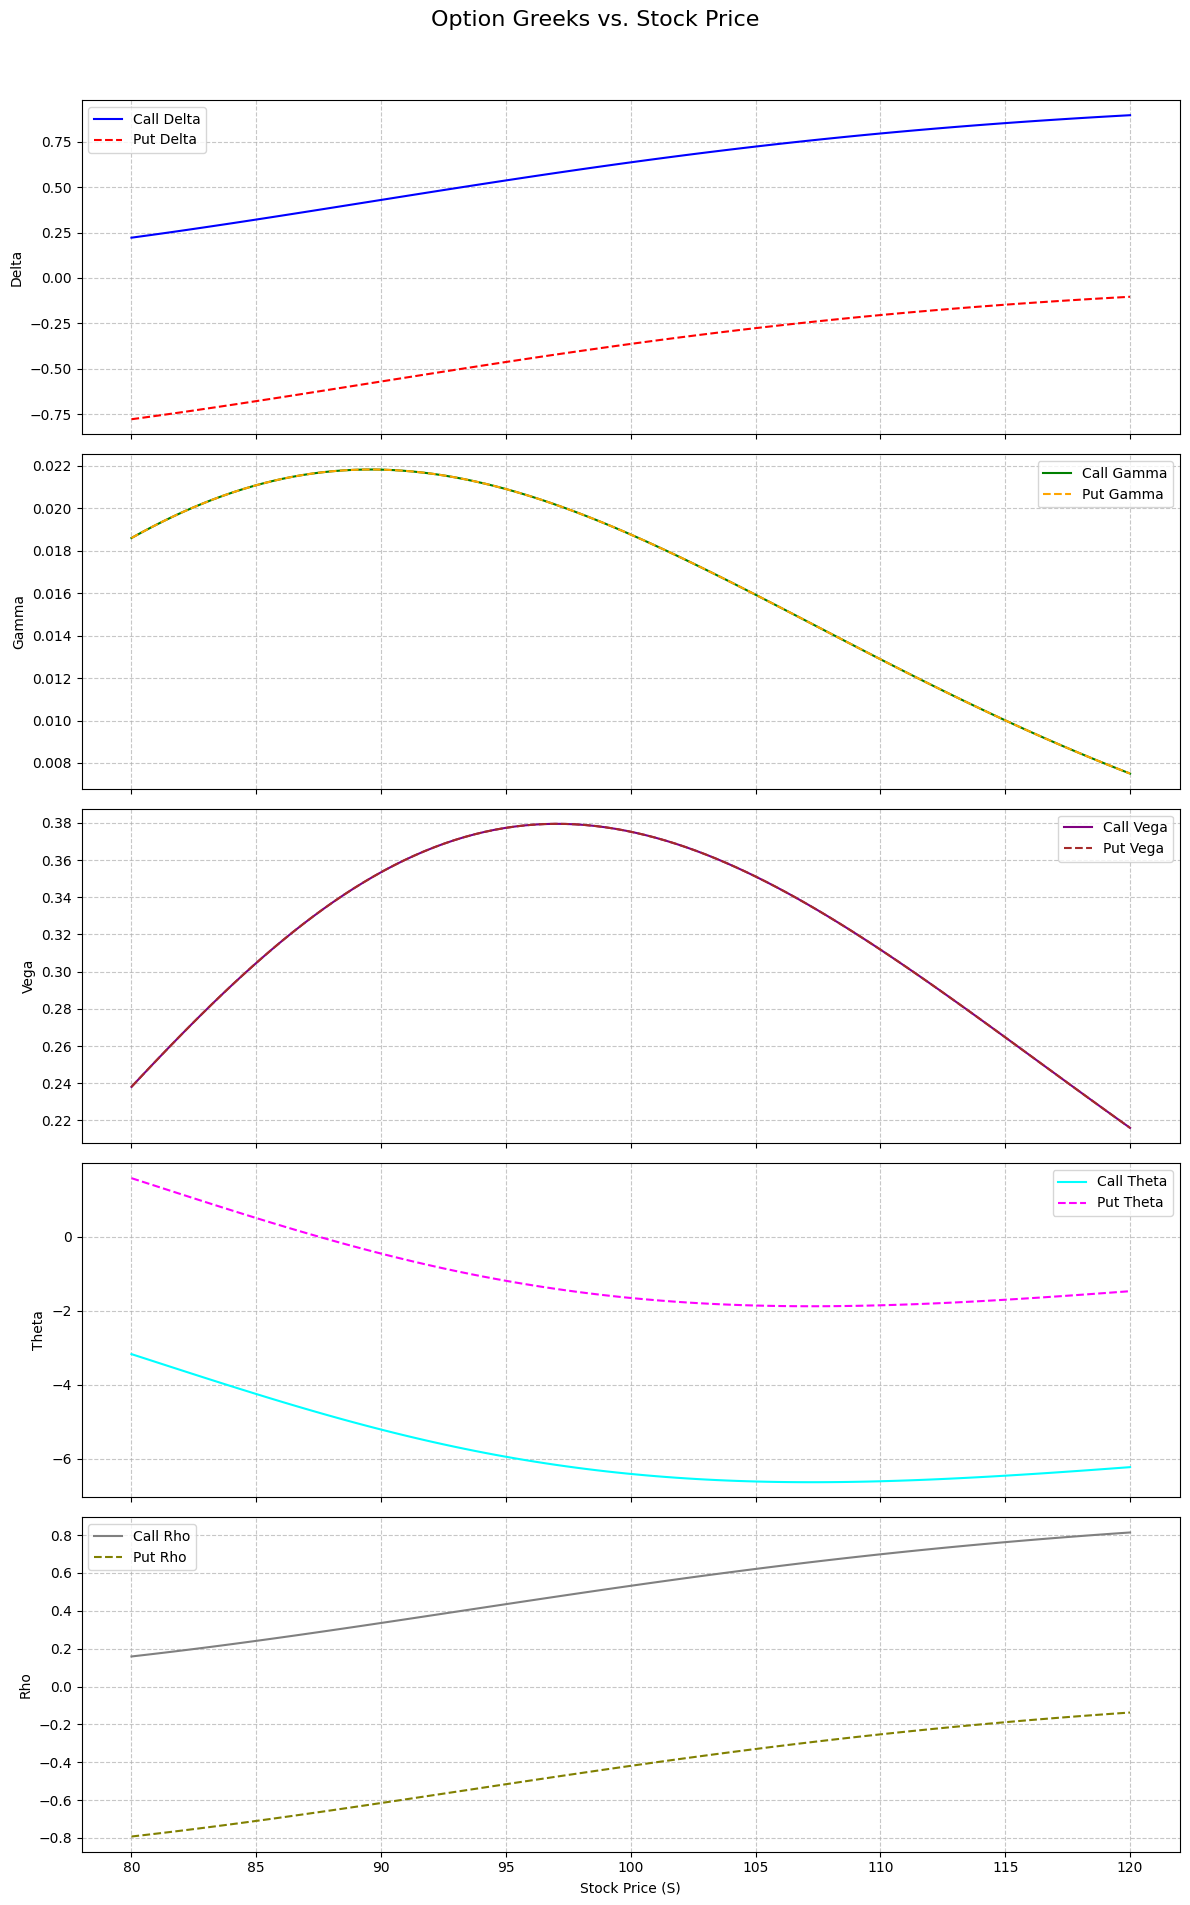

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'engine', 'K', 'T', 'r', 'sigma' are available from previous cells.
# If not, re-initialize:
# engine = OptionPricingEngine()
# K = 100; T = 1; r = 0.05; sigma = 0.20

# Define a range of stock prices around the current price (S=100)
stock_price_range = np.linspace(80, 120, 100)

# Initialize lists to store Greek values for calls and puts
call_deltas, call_gammas, call_vegas, call_thetas, call_rhos = [], [], [], [], []
put_deltas, put_gammas, put_vegas, put_thetas, put_rhos = [], [], [], [], []

for current_S in stock_price_range:
    call_greeks = engine.calculate_greeks(current_S, K, T, r, sigma, option_type='call')
    put_greeks = engine.calculate_greeks(current_S, K, T, r, sigma, option_type='put')

    call_deltas.append(call_greeks['delta'])
    call_gammas.append(call_greeks['gamma'])
    call_vegas.append(call_greeks['vega'])
    call_thetas.append(call_greeks['theta'])
    call_rhos.append(call_greeks['rho'])

    put_deltas.append(put_greeks['delta'])
    put_gammas.append(put_greeks['gamma'])
    put_vegas.append(put_greeks['vega'])
    put_thetas.append(put_greeks['theta'])
    put_rhos.append(put_greeks['rho'])

# Create subplots for each Greek
fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True)
fig.suptitle('Option Greeks vs. Stock Price', fontsize=16)

# Delta Plot
axes[0].plot(stock_price_range, call_deltas, label='Call Delta', color='blue')
axes[0].plot(stock_price_range, put_deltas, label='Put Delta', color='red', linestyle='--')
axes[0].set_ylabel('Delta')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Gamma Plot
axes[1].plot(stock_price_range, call_gammas, label='Call Gamma', color='green')
axes[1].plot(stock_price_range, put_gammas, label='Put Gamma', color='orange', linestyle='--')
axes[1].set_ylabel('Gamma')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# Vega Plot
axes[2].plot(stock_price_range, call_vegas, label='Call Vega', color='purple')
axes[2].plot(stock_price_range, put_vegas, label='Put Vega', color='brown', linestyle='--')
axes[2].set_ylabel('Vega')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

# Theta Plot
axes[3].plot(stock_price_range, call_thetas, label='Call Theta', color='cyan')
axes[3].plot(stock_price_range, put_thetas, label='Put Theta', color='magenta', linestyle='--')
axes[3].set_ylabel('Theta')
axes[3].legend()
axes[3].grid(True, linestyle='--', alpha=0.7)

# Rho Plot
axes[4].plot(stock_price_range, call_rhos, label='Call Rho', color='gray')
axes[4].plot(stock_price_range, put_rhos, label='Put Rho', color='olive', linestyle='--')
axes[4].set_ylabel('Rho')
axes[4].set_xlabel('Stock Price (S)')
axes[4].legend()
axes[4].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent overlapping titles
plt.show()